In [3]:
!pip install pytrends
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

Setup pytrend library and keyword define

In [27]:
pytrends=TrendReq(hl='en-US',tz=360)
keyword="Golden Retriever"

Data Request

In [28]:
pytrends.build_payload([keyword],cat=0,timeframe='today 12-m',geo='',gprop='')

Country wise interest

In [29]:
region_data=pytrends.interest_by_region()
region_data=region_data.sort_values(by=keyword,ascending=False).head(15)

/tmp/ipykernel_818/464813007.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




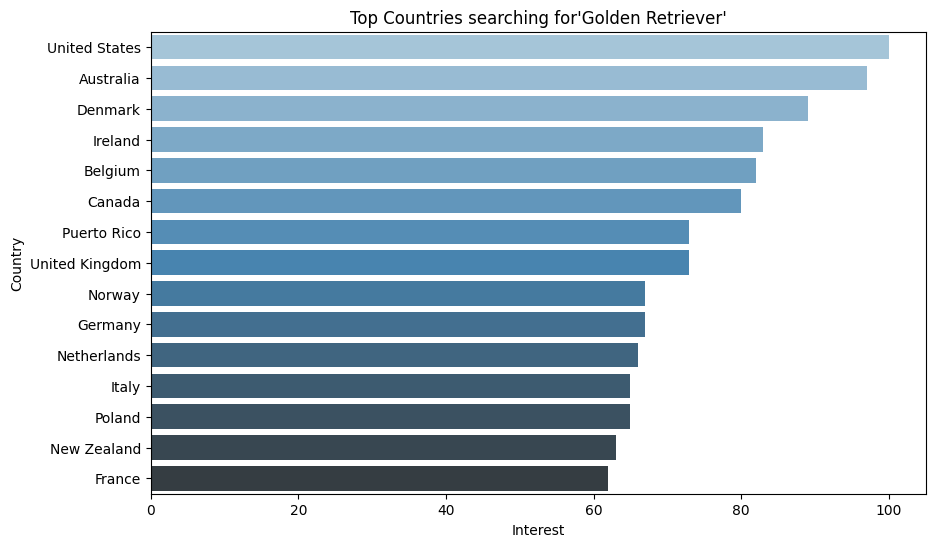

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette="Blues_d")
plt.title(f"Top Countries searching for'{keyword}'")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()

World Map

In [ ]:
region_data=region_data.reset_index()
fig=px.choropleth(region_data,
                  locations='geoName',
                  locationmode='country names',
                  color=keyword,
                  title=f"Search Interest for '{keyword}' by Country",
                  color_continuous_scale='Blues')
fig.show()

: 

Time Wise Interest

In [32]:
time_df=pytrends.interest_over_time()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



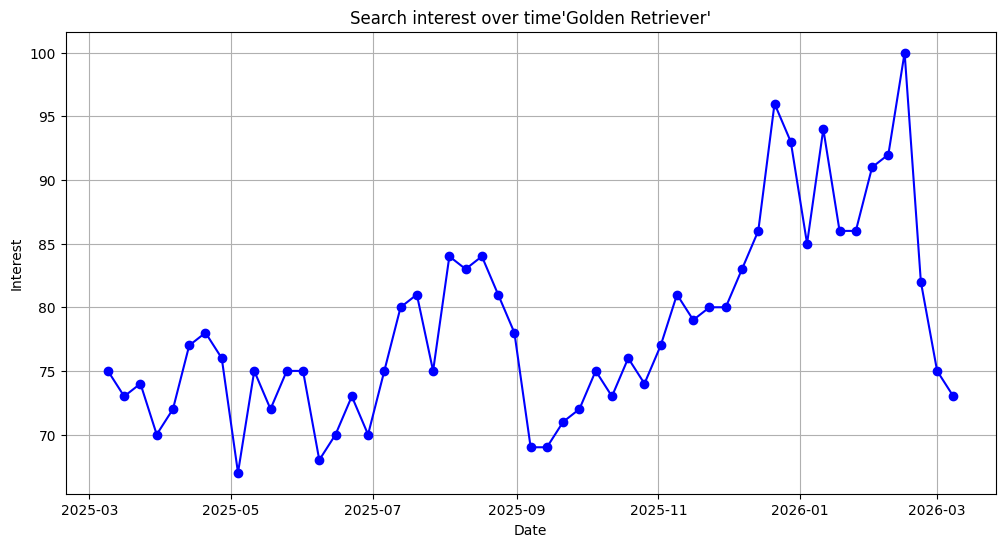

In [33]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index,time_df[keyword],marker='o',color='blue')
plt.title(f"Search interest over time'{keyword}'")
plt.xlabel('Date')
plt.ylabel('Interest')
plt.grid(True)
plt.show()

Multiple Keywords Comparison

In [34]:
kw_list=["Golden Retriever","Siberian Husky","German Shepherd"]
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



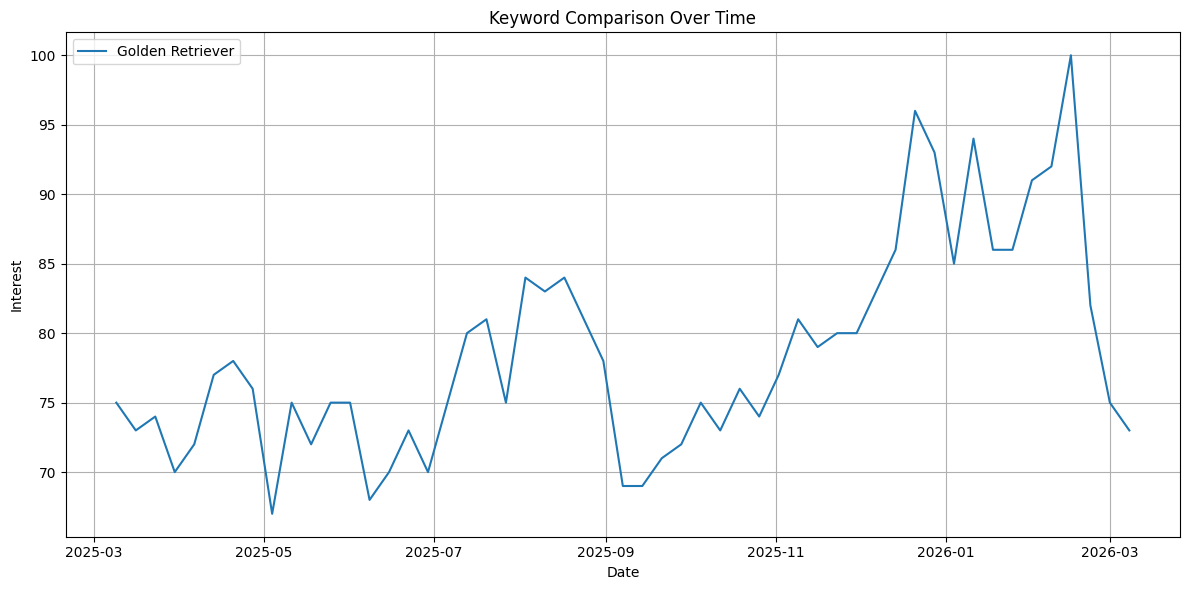

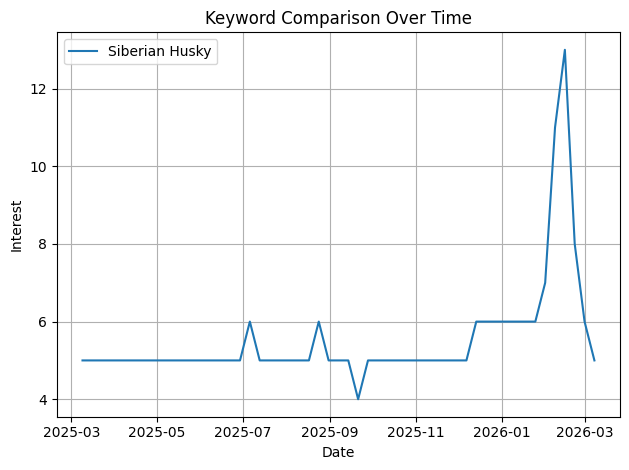

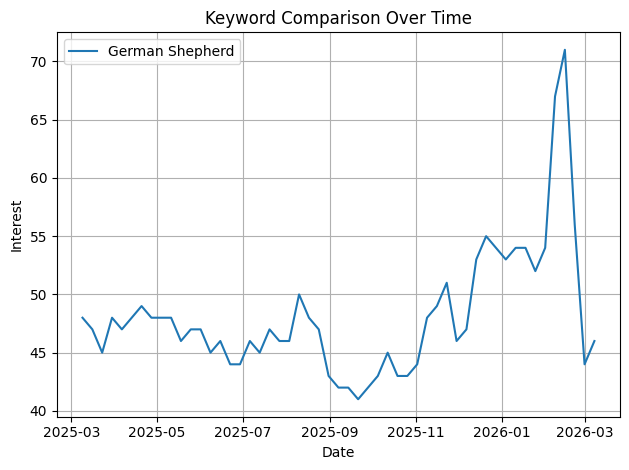

In [35]:
compare_df=pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
  plt.plot(compare_df.index,compare_df[kw],label=kw)
  plt.title("Keyword Comparison Over Time")
  plt.xlabel("Date")
  plt.ylabel("Interest")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()